# マウナ・ロア気象観測所の$\mathsf{CO_2}$データ
- Python の vega_datasets というライブラリには，学習用の各種データセットが含まれている
- ここでは，その中からマウナ・ロア気象観測所の$\mathsf{CO_2}$データを時系列データとして利用する
- Date は日付 (西暦)，CO2 の単位は ppm (parts per million = 百万分率) である

※ このデータは局所的な大気変動の影響を受けにくい高高度で測定した大気中の$\mathsf{CO_2}$の  
　 データであって，マウナ・ロア山が排出する$\mathsf{CO_2}$のデータ**ではない!!**

※ 例によって，各コードの意味は理解しなくてもよい．何をしているのかをよく見ておくこと

In [1]:
# vega_datasets ライブラリから data モジュールをインポートする
from vega_datasets import data

# data モジュールから目的のデータを取得して，変数 co2 に代入する
co2 = data.co2_concentration()

# co2 の表示
display(co2)

,Date,CO2
0,1958-03-01,315.70
1,1958-04-01,317.46
2,1958-05-01,317.51
3,1958-07-01,315.86
4,1958-08-01,314.93
...,...,...
708,2017-08-01,405.24
709,2017-09-01,403.27
710,2017-10-01,403.64
711,2017-11-01,405.17


### データの概観

In [2]:
# グラフの表示のために，plotly.express ライブラリをインポートする
import plotly.express as px

# co2 の内容をグラフで表示
plot = px.line(co2, x="Date", y="CO2")
display(plot)


### 前処理

In [3]:
# co2 から 'Date', 'CO2' の列だけを取り出し，名前を付け替える
# ('adjusted CO2' という列が含まれていたことがあるので，'Date', 'CO2' だけ抽出)
src = co2[['Date', 'CO2']].rename(columns={"Date":"ds", "CO2":"y"})

# src の表示
display(src)

,ds,y
0,1958-03-01,315.70
1,1958-04-01,317.46
2,1958-05-01,317.51
3,1958-07-01,315.86
4,1958-08-01,314.93
...,...,...
708,2017-08-01,405.24
709,2017-09-01,403.27
710,2017-10-01,403.64
711,2017-11-01,405.17


### 将来予測
- Prophet モジュール (prophet) を使って，co2 の将来の推移を予測する
- Prophet モジュールは，STAN というベイズ統計モデルを扱うシステムを利用している
  - ベイズ統計モデルは過去の観測値から将来の値を確率的に推定するモデルである

In [4]:
# prophet ライブラリから Prophet モジュールをインポートする
from prophet import Prophet

# 新規に Prophet モデルを生成し，src にフィッティングさせる
model = Prophet(weekly_seasonality=False, daily_seasonality=False)
model.fit(src)

# model の ds を240か月延長したデータフレームを生成して future に代入する
future = model.make_future_dataframe(periods=240, freq="ME")

# future の表示
display(future)

c:\ProgramData\Miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

19:43:11 - cmdstanpy - INFO - Chain [1] start processing
19:43:12 - cmdstanpy - INFO - Chain [1] done processing


,ds
0,1958-03-01
1,1958-04-01
2,1958-05-01
3,1958-07-01
4,1958-08-01
...,...
948,2037-07-31
949,2037-08-31
950,2037-09-30
951,2037-10-31


In [5]:
# future で延長した期間を model を用いて予測し，結果のデータフレームを forecast に代入する
forecast = model.predict(future)

# forecast の表示
display(forecast)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1958-03-01,314.880155,315.668522,316.789409,314.880155,314.880155,1.349372,1.349372,1.349372,1.349372,1.349372,1.349372,0.0,0.0,0.0,316.229527
1,1958-04-01,314.954957,317.048934,318.124264,314.954957,314.954957,2.595602,2.595602,2.595602,2.595602,2.595602,2.595602,0.0,0.0,0.0,317.550559
2,1958-05-01,315.027346,317.573747,318.654117,315.027346,315.027346,3.069187,3.069187,3.069187,3.069187,3.069187,3.069187,0.0,0.0,0.0,318.096533
3,1958-07-01,315.174538,315.325485,316.482163,315.174538,315.174538,0.759527,0.759527,0.759527,0.759527,0.759527,0.759527,0.0,0.0,0.0,315.934065
4,1958-08-01,315.249340,313.324266,314.412048,315.249340,315.249340,-1.366576,-1.366576,-1.366576,-1.366576,-1.366576,-1.366576,0.0,0.0,0.0,313.882764
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
948,2037-07-31,450.779605,429.013510,470.073846,430.248769,471.201368,-1.315011,-1.315011,-1.315011,-1.315011,-1.315011,-1.315011,0.0,0.0,0.0,449.464594
949,2037-08-31,450.969654,426.857427,468.364739,430.264465,471.465157,-3.119920,-3.119920,-3.119920,-3.119920,-3.119920,-3.119920,0.0,0.0,0.0,447.849733
950,2037-09-30,451.153571,427.172958,468.383186,430.274031,471.824145,-3.424580,-3.424580,-3.424580,-3.424580,-3.424580,-3.424580,0.0,0.0,0.0,447.728991
951,2037-10-31,451.343619,428.370242,469.938633,430.289727,472.154633,-2.100664,-2.100664,-2.100664,-2.100664,-2.100664,-2.100664,0.0,0.0,0.0,449.242955


c:\ProgramData\Miniconda3\Lib\site-packages\prophet\plot.py:72: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\ProgramData\Miniconda3\Lib\site-packages\prophet\plot.py:73: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



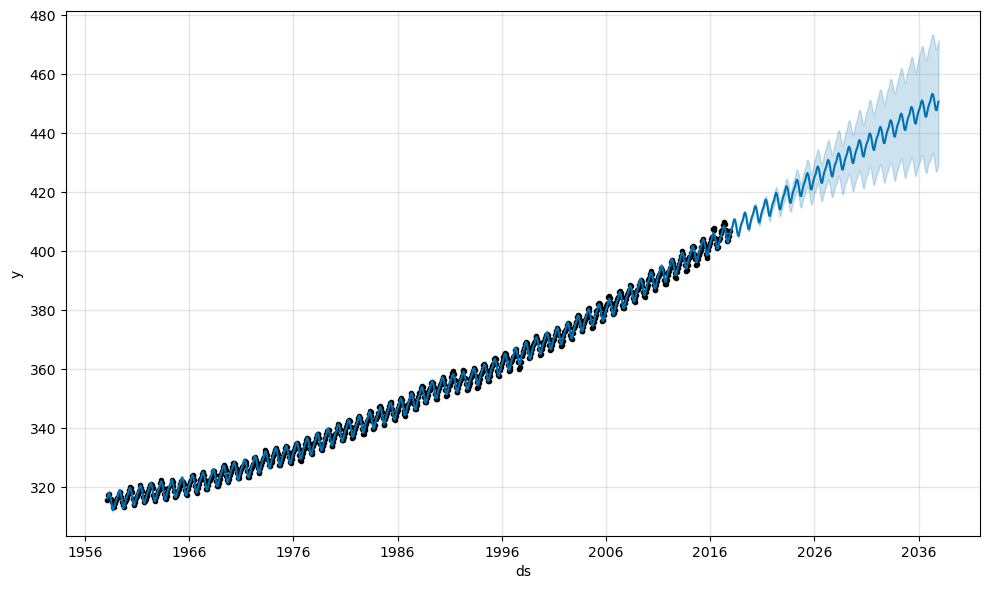

In [6]:
# forecast の予測値 (yhat) のグラフを表示する
# 黒いプロットは観測値
# 色付きの範囲は予測の上下限を表す (デフォルトでは80%信頼区間)
_ = model.plot(forecast)

c:\ProgramData\Miniconda3\Lib\site-packages\prophet\plot.py:228: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\ProgramData\Miniconda3\Lib\site-packages\prophet\plot.py:351: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result

c:\ProgramData\Miniconda3\Lib\site-packages\prophet\plot.py:354: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



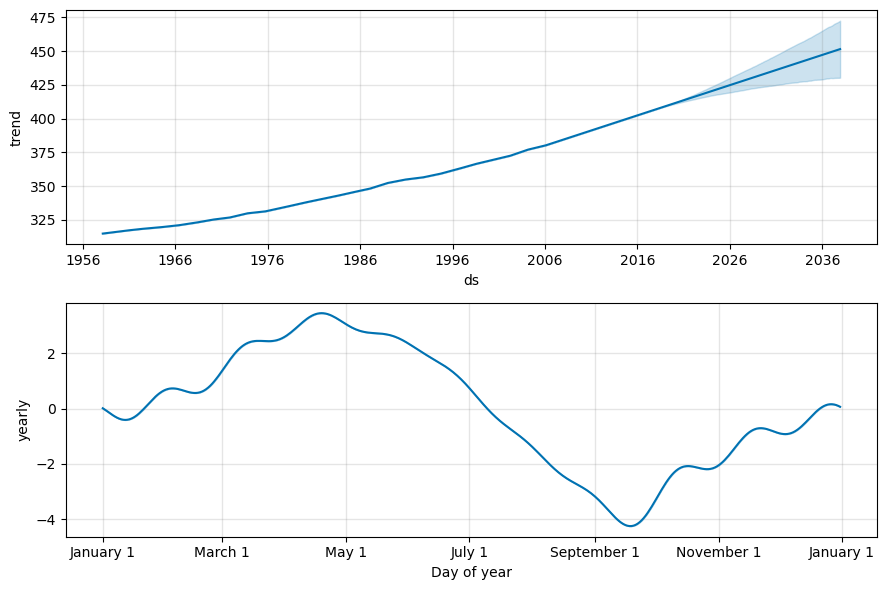

In [7]:
# 傾向変動 (trend) と季節変動 (yearly) のグラフを表示する
_ = model.plot_components(forecast)

In [8]:
# forecast のうち，値 0 の列と，yearly と同じ値の列を除き，並べ替えた列:
# (ds,   yhat,  yhat_lower, yhat_upper, trend,   trend_lower, trend_upper, yearly)
# (日付, 予測値, …の下限,    …の上限,     傾向変動, …の下限,     …の上限,      季節変動)
# の dataframe を生成して forecast2 に代入

forecast2 = forecast[["ds", "yhat", "yhat_lower", "yhat_upper", "trend", "trend_lower", "trend_upper", "yearly"]]

# 日付 (ds) と予測値 (yhat) の間に実測値 (y) の列を追加
forecast2.insert(1, "y", src["y"])

# forecast2 の先頭10行 (1年分(6,10月欠損)) と末尾12行 (1年分) の表示
display(forecast2.head(10))
display(forecast2.tail(12))

,ds,y,yhat,yhat_lower,yhat_upper,trend,trend_lower,trend_upper,yearly
0,1958-03-01,315.70,316.229527,315.668522,316.789409,314.880155,314.880155,314.880155,1.349372
1,1958-04-01,317.46,317.550559,317.048934,318.124264,314.954957,314.954957,314.954957,2.595602
2,1958-05-01,317.51,318.096533,317.573747,318.654117,315.027346,315.027346,315.027346,3.069187
3,1958-07-01,315.86,315.934065,315.325485,316.482163,315.174538,315.174538,315.174538,0.759527
4,1958-08-01,314.93,313.882764,313.324266,314.412048,315.249340,315.249340,315.249340,-1.366576
5,1958-09-01,313.21,312.157536,311.617597,312.684597,315.324142,315.324142,315.324142,-3.166606
6,1958-11-01,313.33,313.404341,312.880119,313.943238,315.471334,315.471334,315.471334,-2.066993
7,1958-12-01,314.67,314.654850,314.091192,315.203330,315.543723,315.543723,315.543723,-0.888873
8,1959-01-01,315.58,315.653183,315.077364,316.202050,315.618525,315.618525,315.618525,0.034658
9,1959-02-01,316.48,316.359160,315.807871,316.935957,315.693327,315.693327,315.693327,0.665833


,ds,y,yhat,yhat_lower,yhat_upper,trend,trend_lower,trend_upper,yearly
941,2036-12-31,NaN,449.535656,429.995092,468.940605,449.479921,430.110347,468.856794,0.055736
942,2037-01-31,NaN,450.317768,430.494504,469.715533,449.669969,430.055519,469.227798,0.647799
943,2037-02-28,NaN,451.113086,431.178286,471.105960,449.841625,430.075165,469.640042,1.271461
944,2037-03-31,NaN,452.596436,432.371361,472.339292,450.031674,430.146751,470.070679,2.564763
945,2037-04-30,NaN,453.319412,433.273500,473.439461,450.215591,430.209943,470.416130,3.103821
946,2037-05-31,NaN,452.798842,432.665860,473.218117,450.405639,430.223506,470.679919,2.393203
947,2037-06-30,NaN,451.410271,431.079741,471.713986,450.589557,430.233072,470.937578,0.820714
948,2037-07-31,NaN,449.464594,429.013510,470.073846,450.779605,430.248769,471.201368,-1.315011
949,2037-08-31,NaN,447.849733,426.857427,468.364739,450.969654,430.264465,471.465157,-3.119920
950,2037-09-30,NaN,447.728991,427.172958,468.383186,451.153571,430.274031,471.824145,-3.424580


In [9]:
# CSVファイルに保存

forecast2.to_csv("co2Prophet.csv", index=False)